# Laboratorio 5 — Modelo espacial de cobertura hospitalaria
CC2017 – Modelación y Simulación

## Task 1.1.a — Carga de los cuatro archivos de datos

Se cargan los dos archivos vectoriales de geometría (`hospitales_eeuu.geojson`, `condados_eeuu.geojson`, `estados_eeuu.geojson`) con GeoPandas y la tabla de población (`poblacion_condados.csv`) con Pandas. Para cada uno se reporta número de registros, CRS (cuando aplica) y columnas disponibles, tal como pide el enunciado.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../data"

hospitales = gpd.read_file(f"{DATA_DIR}/hospitales_eeuu.geojson")
condados = gpd.read_file(f"{DATA_DIR}/condados_eeuu.geojson")
estados = gpd.read_file(f"{DATA_DIR}/estados_eeuu.geojson")
poblacion = pd.read_csv(f"{DATA_DIR}/poblacion_condados.csv")

datasets = {
    "hospitales_eeuu.geojson": hospitales,
    "condados_eeuu.geojson": condados,
    "estados_eeuu.geojson": estados,
}

for nombre, gdf in datasets.items():
    print(f"--- {nombre} ---")
    print(f"Registros: {len(gdf)}")
    print(f"CRS: {gdf.crs}")
    print(f"Columnas: {list(gdf.columns)}")
    print()

print("--- poblacion_condados.csv ---")
print(f"Registros: {len(poblacion)}")
print("CRS: no aplica (tabla tabular, sin geometría)")
print(f"Columnas: {list(poblacion.columns)}")

--- hospitales_eeuu.geojson ---
Registros: 7154
CRS: EPSG:4326
Columnas: ['nombre', 'tipo', 'ciudad', 'estado', 'condado', 'fips_condado', 'camas_total', 'camas_icu', 'camas_licenciadas', 'ocupacion_total', 'ocupacion_icu', 'geometry']

--- condados_eeuu.geojson ---
Registros: 3221
CRS: EPSG:4326
Columnas: ['fips', 'nombre', 'cod_estado', 'geometry']

--- estados_eeuu.geojson ---
Registros: 51
CRS: EPSG:4326
Columnas: ['nombre', 'codigo', 'pais', 'geometry']

--- poblacion_condados.csv ---
Registros: 3246
CRS: no aplica (tabla tabular, sin geometría)
Columnas: ['fips', 'condado', 'estado', 'lat', 'lon', 'poblacion']


## Task 1.1.b — Limpieza previa al filtro por estado

**Población**: se eliminan los códigos FIPS >= 80000 (casos especiales, no son condados reales) y se castea `fips` a string de 5 dígitos con ceros a la izquierda para que calce con `condados.fips`.

**Hospitales**: se reporta el porcentaje de `camas_total` nulo sobre el dataset completo. El resto del laboratorio trabaja solo con hospitales que tienen dato de camas.

In [2]:
n_pob_antes = len(poblacion)
poblacion = poblacion[poblacion["fips"] < 80000].copy()
n_pob_despues = len(poblacion)
print(f"Población: {n_pob_antes - n_pob_despues} registros eliminados (fips >= 80000). Quedan {n_pob_despues}.")

poblacion["fips"] = poblacion["fips"].astype(str).str.zfill(5)
print(poblacion["fips"].head())

pct_camas_nulas = hospitales["camas_total"].isna().mean() * 100
print(f"\n% de hospitales con camas_total nulo (dataset completo EE.UU.): {pct_camas_nulas:.2f}%")

hospitales_con_camas = hospitales[hospitales["camas_total"].notna()].copy()
print(f"Hospitales con camas_total disponible (EE.UU.): {len(hospitales_con_camas)} de {len(hospitales)}")

Población: 102 registros eliminados (fips >= 80000). Quedan 3144.
102    01001
103    01003
104    01005
105    01007
106    01009
Name: fips, dtype: str

% de hospitales con camas_total nulo (dataset completo EE.UU.): 15.24%
Hospitales con camas_total disponible (EE.UU.): 6064 de 7154


## Elección del estado

Se cuenta el número de hospitales (con dato de camas) por estado para elegir uno con al menos 50 hospitales, como recomienda el enunciado.

In [3]:
conteo_por_estado = hospitales_con_camas["estado"].value_counts()
print(conteo_por_estado.head(15))
print(f"\nEstados con >= 50 hospitales: {(conteo_por_estado >= 50).sum()}")

estado
TX    591
CA    440
FL    305
OH    235
PA    231
NY    206
IL    194
LA    190
GA    164
IN    158
MI    153
KS    149
OK    145
WI    144
MO    142
Name: count, dtype: int64

Estados con >= 50 hospitales: 40


In [4]:
print("condados.cod_estado dtype:", condados["cod_estado"].dtype)
print(condados["cod_estado"].unique()[:10])
print()
print("estados.codigo dtype:", estados["codigo"].dtype)
print(estados[["nombre", "codigo"]].head(10))
print()
print("poblacion.estado ejemplos:", poblacion["estado"].unique()[:10])

condados.cod_estado dtype: str
<StringArray>
['01', '02', '05', '06', '08', '12', '13', '09', '04', '15']
Length: 10, dtype: str

estados.codigo dtype: str
         nombre codigo
0    Washington     WA
1         Idaho     ID
2       Montana     MT
3  North Dakota     ND
4     Minnesota     MN
5      Michigan     MI
6          Ohio     OH
7  Pennsylvania     PA
8      New York     NY
9       Vermont     VT

poblacion.estado ejemplos: <StringArray>
[             'Alabama',               'Alaska',              'Arizona',
             'Arkansas',           'California',             'Colorado',
          'Connecticut',             'Delaware', 'District of Columbia',
              'Florida']
Length: 10, dtype: str


### Estado elegido: Indiana

Se elige **Indiana** (abreviatura `IN`, FIPS de estado `18`) porque:
- Tiene 158 hospitales con datos de camas disponibles, muy por encima del mínimo recomendado de 50.
- Su forma es relativamente compacta y rectangular, lo que la hace manejable para los cálculos de buffers, la grilla del Task 2.3 y la descarga de red vial de OSMnx en el Task 3.1 (comparado con estados muy extensos o alargados como Texas o California).
- Se ubica casi enteramente dentro de una sola zona UTM, lo que simplifica la justificación del CRS proyectado (Task 1.1.d).

Claves de filtrado identificadas:
- `hospitales.estado` y `estados.codigo` usan la abreviatura postal (`IN`).
- `condados.cod_estado` usa el código FIPS de estado de 2 dígitos (`18` para Indiana).
- `poblacion.estado` usa el nombre completo (`Indiana`).

## Task 1.1.c — Filtro por estado y unión población–geometría

In [5]:
ESTADO_NOMBRE = "Indiana"
ESTADO_ABBR = "IN"
ESTADO_FIPS = "18"

hosp_estado = hospitales_con_camas[hospitales_con_camas["estado"] == ESTADO_ABBR].copy()
cond_estado = condados[condados["cod_estado"] == ESTADO_FIPS].copy()
estado_geom = estados[estados["codigo"] == ESTADO_ABBR].copy()
pob_estado = poblacion[poblacion["estado"] == ESTADO_NOMBRE].copy()

print(f"Hospitales con camas en {ESTADO_NOMBRE}: {len(hosp_estado)}")
print(f"Condados (geometría) en {ESTADO_NOMBRE}: {len(cond_estado)}")
print(f"Condados (población) en {ESTADO_NOMBRE}: {len(pob_estado)}")

# Unión población + geometría de condados usando fips como llave
cond_estado = cond_estado.merge(pob_estado[["fips", "poblacion"]], on="fips", how="left")

n_con_geom_y_pob = cond_estado["poblacion"].notna().sum()
print(f"\nCondados con geometría Y población tras el join: {n_con_geom_y_pob} de {len(cond_estado)}")
assert len(cond_estado) == len(pob_estado) == n_con_geom_y_pob, "El número de condados con geometría y con población no coincide"
print("Verificación OK: el número de condados con geometría coincide con el número de condados con población.")

Hospitales con camas en Indiana: 158
Condados (geometría) en Indiana: 92
Condados (población) en Indiana: 92

Condados con geometría Y población tras el join: 92 de 92
Verificación OK: el número de condados con geometría coincide con el número de condados con población.


## Task 1.1.d — Reproyección a CRS proyectado en metros

**CRS elegido: EPSG:32616 — WGS 84 / UTM zone 16N**

Justificación: Indiana se extiende aproximadamente entre -88.10° y -84.78° de longitud y 37.77° a 41.76° de latitud. Ese rango de longitud cae **enteramente** dentro de la zona UTM 16N (84°O–90°O), cuyo meridiano central (-87°O) pasa casi por el centro del estado. Al usar una única zona UTM que contiene todo el territorio, la distorsión de escala se mantiene acotada (factor de escala entre 0.9996 en el meridiano central y aproximadamente 1.0004 en los bordes de la zona, es decir, un error relativo máximo del orden de 1:2500), muy inferior al que introduciría una proyección continental (p. ej. Albers CONUS) aplicada a un solo estado. Además, UTM es una proyección conforme (preserva ángulos localmente) y sus unidades son metros, lo que la hace apropiada para medir distancias y construir buffers circulares con precisión.

In [6]:
EPSG_PROYECTADO = 32616  # WGS 84 / UTM zone 16N

hosp_proj = hosp_estado.to_crs(epsg=EPSG_PROYECTADO)
cond_proj = cond_estado.to_crs(epsg=EPSG_PROYECTADO)
estado_proj = estado_geom.to_crs(epsg=EPSG_PROYECTADO)

for nombre, gdf in [("hospitales", hosp_proj), ("condados", cond_proj), ("estado", estado_proj)]:
    print(f"{nombre}: CRS = {gdf.crs.to_epsg()} | unidad = {gdf.crs.axis_info[0].unit_name}")

hospitales: CRS = 32616 | unidad = metre
condados: CRS = 32616 | unidad = metre
estado: CRS = 32616 | unidad = metre


## Task 1.1.e — Mapa de línea base (3 capas)

Condados en gris claro, hospitales como puntos coloreados por `tipo`, y el contorno del estado sin relleno. Se agrega una escala gráfica (dibujada manualmente con una barra de longitud conocida en metros, ya que las capas están en un CRS proyectado) y título.

Tipos de hospital presentes: ['CRITICAL ACCESS', 'GENERAL ACUTE CARE', 'LONG TERM CARE', 'MILITARY', 'PSYCHIATRIC', 'REHABILITATION', 'SPECIAL']


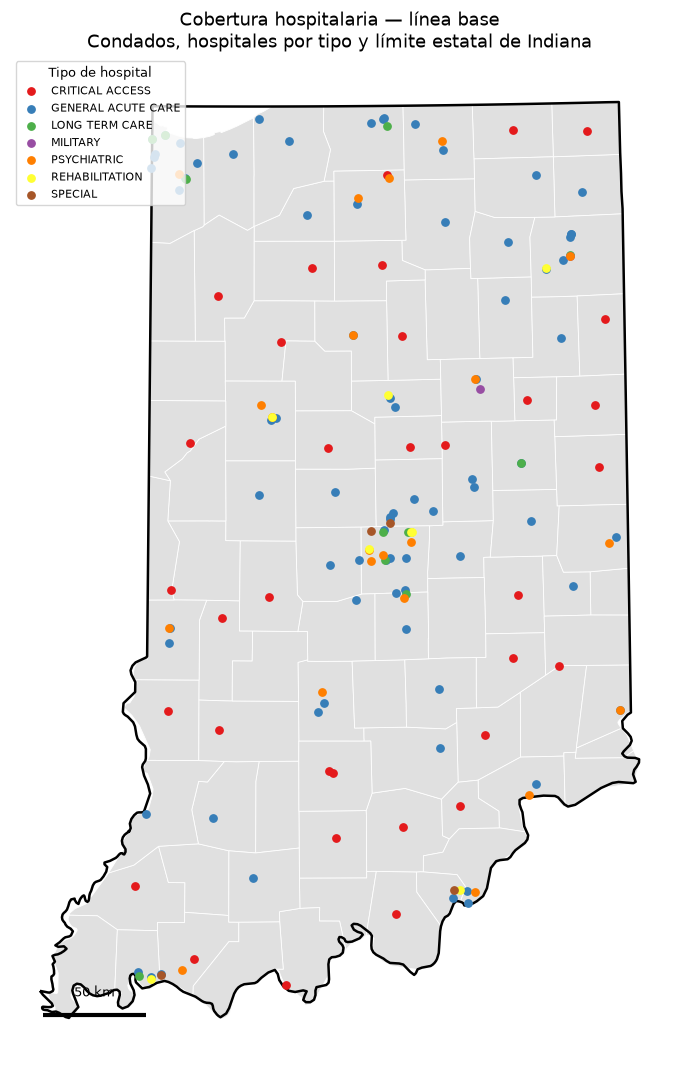

In [7]:
import os
os.makedirs("../outputs", exist_ok=True)

print("Tipos de hospital presentes:", sorted(hosp_proj["tipo"].dropna().unique()))

def agregar_escala(ax, longitud_m=50000, x_frac=0.05, y_frac=0.05):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x0 = xlim[0] + x_frac * (xlim[1] - xlim[0])
    y0 = ylim[0] + y_frac * (ylim[1] - ylim[0])
    ax.plot([x0, x0 + longitud_m], [y0, y0], color="black", linewidth=3, solid_capstyle="butt")
    ax.text(x0 + longitud_m / 2, y0 + 0.015 * (ylim[1] - ylim[0]),
            f"{longitud_m / 1000:.0f} km", ha="center", va="bottom", fontsize=9)

fig, ax = plt.subplots(figsize=(10, 11))

cond_proj.plot(ax=ax, color="#e0e0e0", edgecolor="white", linewidth=0.6, zorder=1)

hosp_proj.plot(ax=ax, column="tipo", categorical=True, legend=True, markersize=28,
               cmap="Set1", zorder=3,
               legend_kwds={"title": "Tipo de hospital", "loc": "upper left", "fontsize": 8, "title_fontsize": 9})

estado_proj.boundary.plot(ax=ax, color="black", linewidth=1.8, zorder=2)

agregar_escala(ax, longitud_m=50000)

ax.set_title(f"Cobertura hospitalaria — línea base\nCondados, hospitales por tipo y límite estatal de {ESTADO_NOMBRE}",
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/task1_1e_mapa_linea_base.png", dpi=150, bbox_inches="tight")
plt.show()

# Task 1.2 — Estadísticas por condado

Se agregan los hospitales por condado (`fips_condado`) y se combinan con la población para calcular camas totales, camas UCI y camas por cada 10,000 habitantes. Los condados sin hospitales quedan con cero en las columnas numéricas.

In [8]:
print("dtype fips_condado (hospitales):", hosp_proj["fips_condado"].dtype)
print(hosp_proj["fips_condado"].head())

agg_hosp = hosp_proj.groupby("fips_condado").agg(
    n_hospitales=("nombre", "count"),
    camas_totales=("camas_total", "sum"),
    camas_uci=("camas_icu", "sum"),
).reset_index()
agg_hosp["fips_condado"] = agg_hosp["fips_condado"].astype(str).str.zfill(5)

tabla_condados = cond_proj[["fips", "nombre", "poblacion", "geometry"]].merge(
    agg_hosp, left_on="fips", right_on="fips_condado", how="left"
).drop(columns="fips_condado")

for col in ["n_hospitales", "camas_totales", "camas_uci"]:
    tabla_condados[col] = tabla_condados[col].fillna(0)

tabla_condados["camas_x10k"] = tabla_condados["camas_totales"] / tabla_condados["poblacion"] * 10000
tabla_condados["camas_uci_x10k"] = tabla_condados["camas_uci"] / tabla_condados["poblacion"] * 10000

print(f"\nCondados sin hospitales: {(tabla_condados['n_hospitales'] == 0).sum()} de {len(tabla_condados)}")
tabla_condados.drop(columns="geometry").sort_values("nombre").head(10)

dtype fips_condado (hospitales): str
22     18039
59     18097
97     18003
167    18069
176    18005
Name: fips_condado, dtype: str

Condados sin hospitales: 18 de 92


,fips,nombre,poblacion,n_hospitales,camas_totales,camas_uci,camas_x10k,camas_uci_x10k
54,18001,Adams,35777.0,1.0,25.0,4.0,6.987730,1.118037
53,18003,Allen,379299.0,9.0,1344.0,170.0,35.433787,4.481952
67,18005,Bartholomew,83779.0,1.0,211.0,17.0,25.185309,2.029148
45,18007,Benton,8748.0,0.0,0.0,0.0,0.000000,0.000000
15,18009,Blackford,11758.0,1.0,15.0,0.0,12.757272,0.000000
16,18011,Boone,67843.0,1.0,68.0,8.0,10.023142,1.179193
46,18013,Brown,15092.0,0.0,0.0,0.0,0.000000,0.000000
47,18015,Carroll,20257.0,0.0,0.0,0.0,0.000000,0.000000
68,18017,Cass,37689.0,2.0,60.0,5.0,15.919764,1.326647
48,18019,Clark,118302.0,3.0,299.0,22.0,25.274298,1.859647


### Task 1.2.a — Los 5 condados con menor cantidad de camas por habitante (población > 10,000)

In [9]:
condados_grandes = tabla_condados[tabla_condados["poblacion"] > 10000].copy()

mas_vulnerables = condados_grandes.sort_values("camas_x10k").head(5)
mas_vulnerables.drop(columns="geometry")[["nombre", "poblacion", "n_hospitales", "camas_totales", "camas_x10k"]]

,nombre,poblacion,n_hospitales,camas_totales,camas_x10k
8,Pike,12389.0,0.0,0.0,0.0
20,Parke,16937.0,0.0,0.0,0.0
30,Wabash,30996.0,0.0,0.0,0.0
62,Owen,20799.0,0.0,0.0,0.0
42,Martin,10255.0,0.0,0.0,0.0


In [10]:
n_empate_cero = (condados_grandes["camas_x10k"] == 0).sum()
print(f"Condados con población > 10,000 y camas_x10k = 0: {n_empate_cero} de {len(condados_grandes)}")

Condados con población > 10,000 y camas_x10k = 0: 15 de 88


**Interpretación (1.2.a):** entre los 88 condados de Indiana con más de 10,000 habitantes, 15 no tienen ningún hospital con datos de camas, por lo que su tasa de camas por 10,000 habitantes es exactamente cero; los cinco mostrados (Pike, Parke, Wabash, Owen, Martin) son un subconjunto representativo de ese grupo empatado en el valor mínimo posible. Estos condados dependen completamente de hospitales ubicados fuera de su territorio, lo que los convierte en los candidatos más claros a vulnerabilidad de acceso: cualquier atención hospitalaria implica desplazarse a un condado vecino.

### Task 1.2.b — Los 5 condados con mayor concentración de camas por habitante

In [11]:
mas_concentracion = tabla_condados.sort_values("camas_x10k", ascending=False).head(5)
mas_concentracion.drop(columns="geometry")[["nombre", "poblacion", "n_hospitales", "camas_totales", "camas_x10k"]]

,nombre,poblacion,n_hospitales,camas_totales,camas_x10k
38,Jefferson,32308.0,2.0,238.0,73.665965
87,Vanderburgh,181451.0,4.0,1094.0,60.291759
73,Wayne,65884.0,2.0,376.0,57.070002
56,Grant,65769.0,3.0,347.0,52.760419
41,Marion,964582.0,17.0,4072.0,42.215177


**Interpretación (1.2.b):** los cinco condados con mayor concentración de camas por habitante (Jefferson 73.7, Vanderburgh 60.3, Wayne 57.1, Grant 52.8 y Marion 42.2 camas por 10,000 hab.) **no** representan necesariamente una ventaja de acceso exclusiva para su población residente. Jefferson, Wayne y Grant tienen poblaciones relativamente pequeñas (32k, 66k y 66k habitantes) pero concentran hospitales de tamaño considerable (238, 376 y 347 camas respectivamente): esto es típico de condados que albergan un hospital regional que atiende pacientes referidos de varios condados vecinos sin hospital propio, por lo que la tasa por habitante local sobreestima el acceso real disponible solo para los residentes del condado. El caso de Marion (Indianápolis, 965k habitantes, 4,072 camas) es distinto: es el condado más poblado del estado y concentra los sistemas hospitalarios más grandes, funcionando como centro de referencia estatal, por lo que su alta tasa sí refleja en parte capacidad genuina para su población, además de servir como hub regional.

### Task 1.2.c — Distribuciones (histogramas)

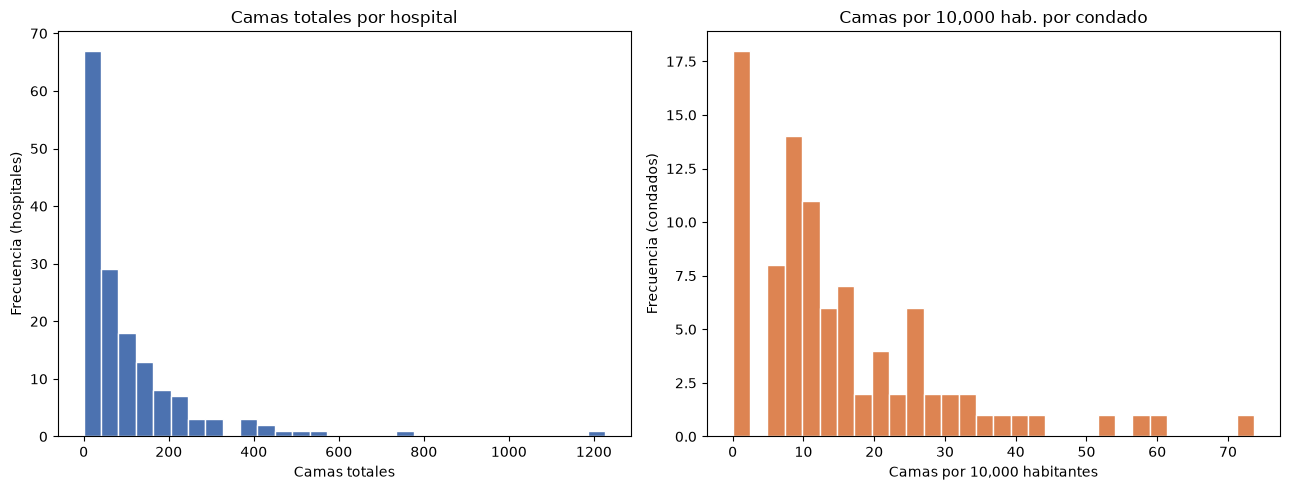

count     158.000000
mean      108.930380
std       150.361946
min         0.000000
25%        25.000000
50%        49.000000
75%       133.750000
max      1226.000000
Name: camas_total, dtype: float64

count    92.000000
mean     15.097164
std      14.467645
min       0.000000
25%       6.904093
50%      10.746290
75%      20.945476
max      73.665965
Name: camas_x10k, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(hosp_proj["camas_total"], bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Camas totales por hospital")
axes[0].set_xlabel("Camas totales")
axes[0].set_ylabel("Frecuencia (hospitales)")

axes[1].hist(tabla_condados["camas_x10k"], bins=30, color="#dd8452", edgecolor="white")
axes[1].set_title("Camas por 10,000 hab. por condado")
axes[1].set_xlabel("Camas por 10,000 habitantes")
axes[1].set_ylabel("Frecuencia (condados)")

plt.tight_layout()
plt.savefig("../outputs/task1_2c_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

print(hosp_proj["camas_total"].describe())
print()
print(tabla_condados["camas_x10k"].describe())

**Interpretación:** ambas distribuciones son fuertemente **asimétricas a la derecha** (sesgo positivo), con valores extremos marcados.

- **Camas por hospital:** la mediana (49 camas) es mucho menor que la media (108.9), y el máximo (1,226 camas) está muy por encima del percentil 75 (133.75). La mayoría de los hospitales de Indiana son pequeños (críticos de acceso rural, <50 camas), mientras que unos pocos hospitales grandes (sistemas urbanos en Indianápolis, Fort Wayne, etc.) concentran una fracción desproporcionada de la capacidad instalada.
- **Camas por 10,000 hab. por condado:** 18 de 92 condados están en la barra de cero (sin hospital), y la cola derecha llega hasta 73.7 camas/10k, muy por encima del percentil 75 (20.9). Esto confirma el patrón detectado en 1.2.b: unos pocos condados con hospitales regionales "inflan" su tasa per cápita.

**Implicación para el análisis de cobertura:** usar promedios simples sería engañoso porque están dominados por los valores extremos de unos pocos condados/hospitales grandes. Es más informativo trabajar con medianas, percentiles o, como se hace en el Task 1.3, con un análisis espacial explícito (buffers) que capture dónde física y geográficamente se concentra esa capacidad, en vez de resumir todo el estado con un solo número agregado.

# Task 1.3 — Análisis de buffer de cobertura

Esta sección implementa las operaciones espaciales de **buffer** e **intersección** presentadas en la diapositiva "Capas y operaciones espaciales" del material de clase (S13 — Redes Parte 2): el buffer define una zona de influencia de radio $d$ alrededor de cada hospital, y la intersección entre el buffer unificado y los polígonos de condado permite responder la pregunta de cobertura: "¿qué porcentaje del territorio/población está dentro del buffer de un servicio?".

### Task 1.3.a — Buffers de 10, 25 y 50 km

Se generan buffers circulares alrededor de cada hospital sobre la capa ya reproyectada a metros (EPSG:32616), y se unen con `shapely.ops.unary_union` para obtener una sola geometría de cobertura por radio (equivalente a la unión de discos $B_r(h) = \{x : \|x - h\| \le r\}$ para todos los hospitales $h$).

In [13]:
from shapely.ops import unary_union

RADIOS_KM = [10, 25, 50]

buffers_union = {}
for r in RADIOS_KM:
    discos = hosp_proj.geometry.buffer(r * 1000)  # metros
    buffers_union[r] = unary_union(discos.values)
    print(f"Radio {r} km: {len(discos)} discos individuales unidos en una sola geometría de cobertura.")

Radio 10 km: 158 discos individuales unidos en una sola geometría de cobertura.
Radio 25 km: 158 discos individuales unidos en una sola geometría de cobertura.
Radio 50 km: 158 discos individuales unidos en una sola geometría de cobertura.


### Task 1.3.b — Fracción de población cubierta por radio

Para cada condado se calcula qué fracción de su área cae dentro del buffer unificado, y se asume población distribuida uniformemente dentro del condado: $\text{pob\_cubierta}_i = \text{poblacion}_i \times \dfrac{\text{área}(C_i \cap B_r)}{\text{área}(C_i)}$. La población cubierta del estado es la suma sobre todos los condados.

In [14]:
cond_proj["area_total_m2"] = cond_proj.geometry.area

resultados_cobertura = []
for r in RADIOS_KM:
    buf = buffers_union[r]
    frac_col = f"frac_cubierta_{r}"
    cond_proj[frac_col] = cond_proj.geometry.apply(
        lambda g: g.intersection(buf).area / g.area if g.area > 0 else 0.0
    )
    cond_proj[f"pob_cubierta_{r}"] = cond_proj[frac_col] * cond_proj["poblacion"]

    pob_cubierta = cond_proj[f"pob_cubierta_{r}"].sum()
    pob_total = cond_proj["poblacion"].sum()
    resultados_cobertura.append({
        "radio_km": r,
        "poblacion_cubierta_estimada": round(pob_cubierta),
        "poblacion_total": int(pob_total),
        "pct_cobertura": round(pob_cubierta / pob_total * 100, 2),
    })

tabla_cobertura = pd.DataFrame(resultados_cobertura)
tabla_cobertura

,radio_km,poblacion_cubierta_estimada,poblacion_total,pct_cobertura
0,10,3291613,6732219,48.89
1,25,6552287,6732219,97.33
2,50,6732219,6732219,100.00


### Task 1.3.c — Mapa de cobertura a 25 km

cobertura_25km_cat
Parcial     46
Completa    46
Name: count, dtype: int64


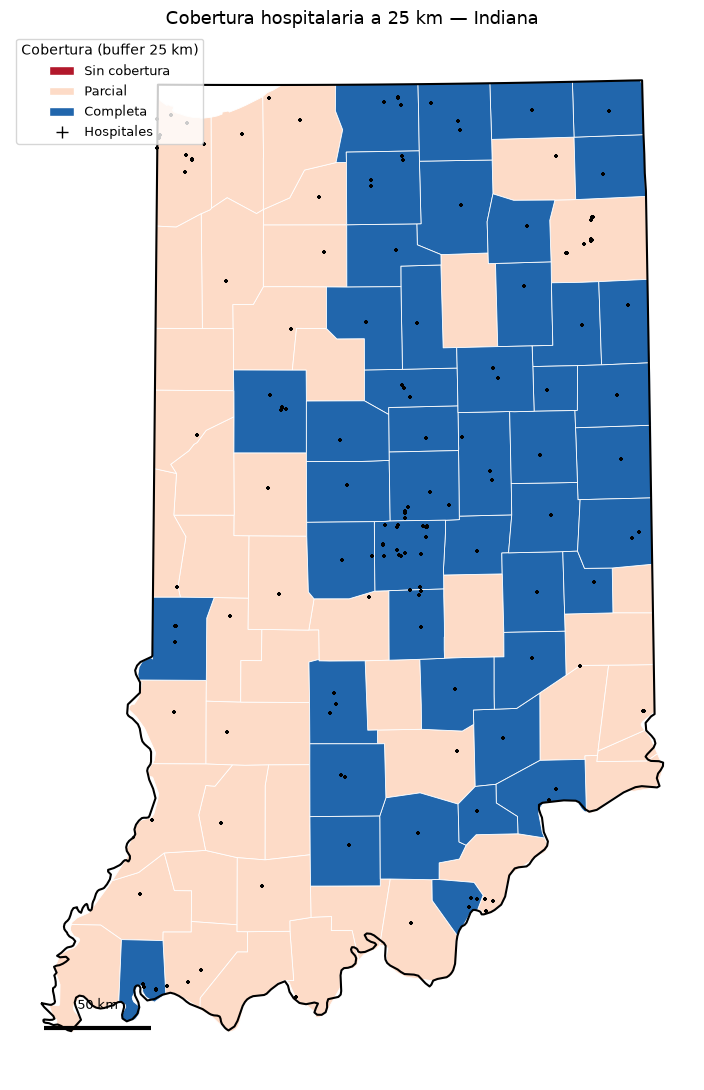

In [15]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def clasificar_cobertura(frac):
    if frac >= 0.999:
        return "Completa"
    elif frac > 0.001:
        return "Parcial"
    else:
        return "Sin cobertura"

cond_proj["cobertura_25km_cat"] = cond_proj["frac_cubierta_25"].apply(clasificar_cobertura)
print(cond_proj["cobertura_25km_cat"].value_counts())

categorias = ["Sin cobertura", "Parcial", "Completa"]
colores = ["#b2182b", "#fddbc7", "#2166ac"]  # rojo -> beige -> azul, escala divergente que resalta zonas sin cobertura
mapa_color = dict(zip(categorias, colores))

fig, ax = plt.subplots(figsize=(10, 11))

for cat in categorias:
    sub = cond_proj[cond_proj["cobertura_25km_cat"] == cat]
    if len(sub) > 0:
        sub.plot(ax=ax, color=mapa_color[cat], edgecolor="white", linewidth=0.6, zorder=1)

estado_proj.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=2)
hosp_proj.plot(ax=ax, color="black", markersize=10, marker="+", zorder=3, label="Hospitales")

agregar_escala(ax, longitud_m=50000)

leyenda = [Patch(facecolor=mapa_color[c], edgecolor="white", label=c) for c in categorias]
leyenda.append(plt.Line2D([0], [0], marker="+", color="black", linestyle="None", markersize=8, label="Hospitales"))
ax.legend(handles=leyenda, loc="upper left", fontsize=9, title="Cobertura (buffer 25 km)")

ax.set_title(f"Cobertura hospitalaria a 25 km — {ESTADO_NOMBRE}", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/task1_3c_mapa_cobertura_25km.png", dpi=150, bbox_inches="tight")
plt.show()

**Lectura de resultados:** con un radio de 10 km la cobertura es de apenas 48.9% de la población; subir a 25 km la eleva a 97.3%; y a 50 km prácticamente el 100% del estado queda cubierto. Esto es consistente con el mapa: a 25 km ningún condado queda totalmente sin cobertura (46 "Completa" / 46 "Parcial" / 0 "Sin cobertura"), pero hay un anillo de condados del norte, oeste y sur con cobertura solo parcial — zonas rurales más alejadas de los hospitales concentrados en el corredor central (Indianápolis) y en los clústeres urbanos del norte y sureste.

# Task 2.1 — Distancia al hospital más cercano

### Task 2.1.a — Distancia por condado (centroide → hospital más cercano)

In [16]:
cond_proj["centroide"] = cond_proj.geometry.centroid

# Distancia euclidiana (en metros, por estar en EPSG:32616) del centroide del condado
# al hospital más cercano: d(C_i, H) = min_h ||centroide(C_i) - h||
cond_proj["dist_hospital_km"] = cond_proj["centroide"].apply(
    lambda p: hosp_proj.geometry.distance(p).min() / 1000
)

top10_lejanos = cond_proj.sort_values("dist_hospital_km", ascending=False).head(10)
top10_lejanos[["nombre", "poblacion", "dist_hospital_km"]]

,nombre,poblacion,dist_hospital_km
45,Benton,8748.0,35.092679
42,Martin,10255.0,30.292806
86,Switzerland,10751.0,29.517089
62,Owen,20799.0,27.422301
46,Brown,15092.0,27.180897
49,Crawford,10577.0,27.108423
30,Wabash,30996.0,26.251315
83,Posey,25427.0,26.202223
8,Pike,12389.0,25.585787
64,Shelby,44729.0,25.032190


### Task 2.1.b — Curva de cobertura acumulada (5 a 100 km, paso 5 km)

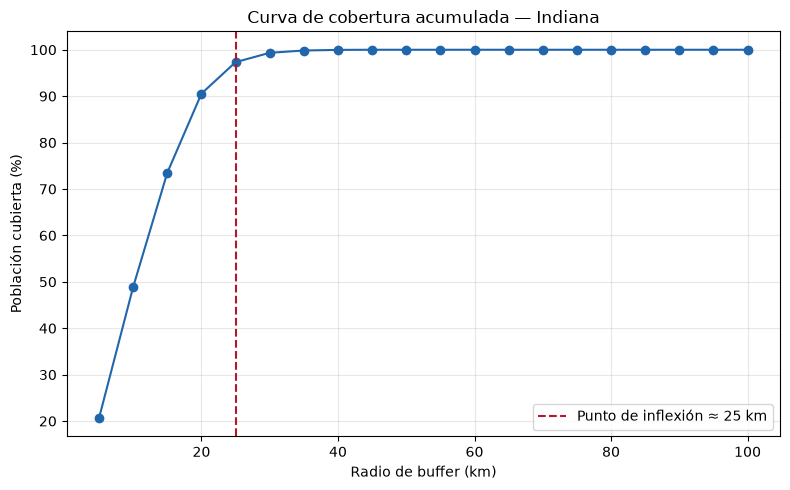

,radio_km,pct_cobertura,delta_pct,delta2_pct
0,5,20.642295,NaN,NaN
1,10,48.893429,28.251134,NaN
2,15,73.499706,24.606276,-3.644858
3,20,90.545052,17.045346,-7.560930
4,25,97.327299,6.782247,-10.263099
5,30,99.343707,2.016408,-4.765839
6,35,99.836046,0.492339,-1.524069
7,40,99.969904,0.133858,-0.358481
8,45,99.999995,0.030091,-0.103767
9,50,100.000000,0.000005,-0.030086


In [17]:
radios_curva = list(range(5, 101, 5))
pob_total_estado = cond_proj["poblacion"].sum()

curva = []
for r in radios_curva:
    buf = unary_union(hosp_proj.geometry.buffer(r * 1000).values)
    frac = cond_proj.geometry.apply(lambda g: g.intersection(buf).area / g.area if g.area > 0 else 0.0)
    pob_cubierta = (frac * cond_proj["poblacion"]).sum()
    curva.append({"radio_km": r, "pct_cobertura": pob_cubierta / pob_total_estado * 100})

tabla_curva = pd.DataFrame(curva)

# Derivadas discretas para localizar el punto de inflexión (máxima desaceleración del crecimiento)
tabla_curva["delta_pct"] = tabla_curva["pct_cobertura"].diff()
tabla_curva["delta2_pct"] = tabla_curva["delta_pct"].diff()
idx_inflexion = tabla_curva["delta2_pct"].idxmin()
radio_inflexion = tabla_curva.loc[idx_inflexion, "radio_km"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabla_curva["radio_km"], tabla_curva["pct_cobertura"], marker="o", color="#2166ac")
ax.axvline(radio_inflexion, color="#b2182b", linestyle="--", label=f"Punto de inflexión ≈ {radio_inflexion} km")
ax.set_xlabel("Radio de buffer (km)")
ax.set_ylabel("Población cubierta (%)")
ax.set_title(f"Curva de cobertura acumulada — {ESTADO_NOMBRE}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/task2_1b_curva_cobertura.png", dpi=150, bbox_inches="tight")
plt.show()

tabla_curva

**Punto de inflexión ≈ 25 km** (máxima caída en la segunda diferencia, de +28.3 puntos porcentuales ganados entre 5→10 km a solo +6.8 puntos entre 20→25 km, y rendimientos ya casi nulos después de 30 km). Para política de acceso hospitalario esto significa que **25 km es el radio donde la inversión en expandir cobertura deja de ser eficiente**: antes de ese punto, cada kilómetro adicional de radio (es decir, cada hospital nuevo que amplía esa distancia de referencia) suma población cubierta a un ritmo alto; después de 25–30 km, el estado ya está casi saturado (97.3% a 99.3%) y agregar capacidad a mayor distancia solo alcanza al 2–3% de población remanente, dispersa en condados rurales de baja densidad. Un plan de expansión que priorice llegar a "cobertura universal" extendiendo el radio más allá de 30 km tendría un costo marginal muy alto por persona adicional cubierta.

### Task 2.1.c — Tipo de hospital más cercano para los 5 condados más alejados

In [18]:
top5_lejanos = top10_lejanos.head(5).copy()

def hospital_mas_cercano(punto):
    idx = hosp_proj.geometry.distance(punto).idxmin()
    return hosp_proj.loc[idx, ["nombre", "tipo", "camas_total", "camas_icu"]]

cercanos = top5_lejanos["centroide"].apply(hospital_mas_cercano)
top5_lejanos = pd.concat([
    top5_lejanos[["nombre", "poblacion", "dist_hospital_km"]].reset_index(drop=True),
    cercanos.reset_index(drop=True).rename(columns={
        "nombre": "hospital_mas_cercano", "tipo": "tipo_hospital", "camas_total": "camas_hospital"
    })
], axis=1)

top5_lejanos

,nombre,poblacion,dist_hospital_km,hospital_mas_cercano,tipo_hospital,camas_hospital,camas_icu
0,Benton,8748.0,35.092679,ST VINCENT WILLIAMSPORT HOSPITAL INC,CRITICAL ACCESS,16.0,NaN
1,Martin,10255.0,30.292806,INDIANA UNIVERSITY HEALTH BEDFORD HOSPITAL,CRITICAL ACCESS,25.0,6.0
2,Switzerland,10751.0,29.517089,KING'S DAUGHTERS' HEALTH,GENERAL ACUTE CARE,88.0,6.0
3,Owen,20799.0,27.422301,BLOOMINGTON MEADOWS HOSPITAL,PSYCHIATRIC,71.0,0.0
4,Brown,15092.0,27.180897,INDIANA UNIVERSITY HEALTH BLOOMINGTON HOSPITAL,GENERAL ACUTE CARE,254.0,30.0


**Interpretación:** entre los 5 condados más alejados, 2 de 5 (Benton y Martin) tienen como hospital más cercano uno de tipo **CRITICAL ACCESS** — por definición federal, hospitales rurales pequeños (≤25 camas) con servicios limitados. Benton (16 camas, sin UCI registrada) y Martin (25 camas, 6 UCI) confirman el patrón: no solo estos condados están más lejos físicamente de cualquier hospital, sino que el hospital que sí tienen cerca es de capacidad mínima. El caso de Owen es aún más revelador: su hospital más cercano (Bloomington Meadows) es **PSIQUIÁTRICO**, no de atención general — es decir, para una emergencia médica general, la distancia real al hospital relevante es mayor que la reportada por la distancia euclidiana al "hospital más cercano" de cualquier tipo. Switzerland y Brown sí tienen cerca hospitales de mayor capacidad (88 y 254 camas), pero aun así a más de 27 km. En conjunto, los datos apoyan la hipótesis de que la lejanía geográfica y la baja capacidad del hospital más cercano tienden a coincidir en los mismos condados rurales, agravando su vulnerabilidad.

# Task 2.2 — Índice compuesto de vulnerabilidad de acceso hospitalario

Se combinan tres componentes normalizados: (1) distancia al hospital más cercano, (2) inverso de camas por habitante, (3) ocupación promedio de hospitales dentro de 50 km.

In [19]:
print(hosp_proj["ocupacion_total"].describe())
print("\nNulos en ocupacion_total:", hosp_proj["ocupacion_total"].isna().sum(), "de", len(hosp_proj))

# Traemos camas_x10k (calculado en Task 1.2) a cond_proj
cond_proj = cond_proj.merge(tabla_condados[["fips", "camas_x10k"]], on="fips", how="left")

count    156.000000
mean       0.480086
std        0.208883
min        0.000000
25%        0.340000
50%        0.466206
75%        0.648737
max        0.971193
Name: ocupacion_total, dtype: float64

Nulos en ocupacion_total: 2 de 158


### Task 2.2.a — Cálculo y normalización min-max de los tres componentes

Min-max: $z_i = \dfrac{x_i - \min(x)}{\max(x) - \min(x)} \in [0,1]$

In [20]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

# Componente 1: distancia al hospital más cercano (ya calculada en Task 2.1.a)
comp1_raw = cond_proj["dist_hospital_km"]

# Componente 2: inverso de camas por habitante. Condados sin hospitales -> valor máximo antes de normalizar.
inv_camas = 1.0 / cond_proj["camas_x10k"].replace(0, np.nan)
max_inv_camas = inv_camas.max()
comp2_raw = inv_camas.fillna(max_inv_camas)

# Componente 3: ocupación promedio de hospitales dentro de 50 km del centroide del condado.
# Condados sin ningún hospital en ese radio -> valor máximo antes de normalizar.
def ocupacion_promedio_50km(punto):
    dists = hosp_proj.geometry.distance(punto)
    cercanos = hosp_proj.loc[dists <= 50000, "ocupacion_total"].dropna()
    return cercanos.mean() if len(cercanos) > 0 else np.nan

comp3_raw = cond_proj["centroide"].apply(ocupacion_promedio_50km)
max_ocupacion = comp3_raw.max()
comp3_raw = comp3_raw.fillna(max_ocupacion)

print(f"Condados sin hospital (comp2 = máximo asignado): {cond_proj['camas_x10k'].eq(0).sum()}")
print(f"Condados sin hospital en 50km (comp3 = máximo asignado): {cond_proj['centroide'].apply(ocupacion_promedio_50km).isna().sum()}")

cond_proj["comp1_norm"] = minmax(comp1_raw)
cond_proj["comp2_norm"] = minmax(comp2_raw)
cond_proj["comp3_norm"] = minmax(comp3_raw)

cond_proj[["nombre", "comp1_norm", "comp2_norm", "comp3_norm"]].describe()

Condados sin hospital (comp2 = máximo asignado): 18
Condados sin hospital en 50km (comp3 = máximo asignado): 0


,comp1_norm,comp2_norm,comp3_norm
count,92.000000,92.000000,92.000000
mean,0.267763,0.544879,0.548538
std,0.257087,0.338460,0.220695
min,0.000000,0.000000,0.000000
25%,0.083243,0.230333,0.399288
50%,0.149937,0.535684,0.544527
75%,0.426900,0.884480,0.719710
max,1.000000,1.000000,1.000000


**Justificación de min-max:** es apropiada aquí porque (1) los tres componentes tienen escalas y unidades completamente distintas (km, camas⁻¹, fracción de ocupación), y min-max las lleva a un rango común [0,1] comparable para poder promediarlas; (2) al laboratorio le interesa la **posición relativa** de cada condado dentro del propio estado analizado (¿quién es el más/menos vulnerable de Indiana?), no una magnitud absoluta comparable entre estados, y min-max está diseñada exactamente para eso. 

**Cuándo NO sería apropiada:** min-max es muy sensible a valores atípicos extremos, porque el máximo (o mínimo) de la muestra define los extremos de la escala — un solo condado con una distancia o una ocupación anómalamente alta "comprime" artificialmente a todos los demás hacia 0. También deja de ser apropiada si se quisiera comparar el índice entre distintos estados analizados por separado (cada uno normalizado con su propio mínimo y máximo no es comparable entre sí), o si la variable no tiene una escala acotada de forma natural y se prefiere preservar la forma de la distribución original (en ese caso una estandarización z-score o una transformación robusta a outliers, como min-max con recorte de percentiles, sería más adecuada).

### Task 2.2.b — Índice compuesto (promedio ponderado)

Pesos elegidos: **distancia 0.45, camas per cápita 0.35, ocupación 0.20**.

- **Distancia (0.45, el mayor peso):** en una emergencia médica el tiempo de traslado es el factor más directamente ligado a morbimortalidad (paro cardíaco, trauma, parto complicado); es también la variable menos manipulable a corto plazo por política pública (no se puede "mover" un condado), por lo que debe dominar el índice.
- **Camas per cápita (0.35):** mide si, una vez que el paciente llega, existe capacidad instalada suficiente para atenderlo; es casi tan importante como la distancia pero es una condición de "stock" estructural que cambia lentamente (requiere construir/ampliar hospitales).
- **Ocupación dentro de 50 km (0.20, el menor peso):** mide saturación en un momento dado; es relevante pero es la variable más volátil en el tiempo (cambia día a día con la demanda) y más indirecta como proxy de vulnerabilidad estructural, por eso recibe el peso menor, sin dejar de incluirse porque un condado con poca distancia y buenas camas per cápita puede igual estar mal servido si sus hospitales cercanos están saturados.

In [21]:
PESOS = {"distancia": 0.45, "camas": 0.35, "ocupacion": 0.20}
assert abs(sum(PESOS.values()) - 1.0) < 1e-9

cond_proj["indice_vulnerabilidad"] = (
    PESOS["distancia"] * cond_proj["comp1_norm"]
    + PESOS["camas"] * cond_proj["comp2_norm"]
    + PESOS["ocupacion"] * cond_proj["comp3_norm"]
)

top10_vulnerables = cond_proj.sort_values("indice_vulnerabilidad", ascending=False).head(10)
top10_vulnerables[["nombre", "comp1_norm", "comp2_norm", "comp3_norm", "indice_vulnerabilidad"]]

,nombre,comp1_norm,comp2_norm,comp3_norm,indice_vulnerabilidad
45,Benton,1.000000,1.0,0.623626,0.924725
83,Posey,0.743910,1.0,1.000000,0.884759
86,Switzerland,0.839395,1.0,0.666800,0.861088
85,Spencer,0.636268,1.0,0.886568,0.813634
64,Shelby,0.710207,1.0,0.708649,0.811323
46,Brown,0.772101,1.0,0.547442,0.806934
30,Wabash,0.745324,1.0,0.497398,0.784875
47,Carroll,0.707562,1.0,0.575402,0.783483
62,Owen,0.779054,1.0,0.356146,0.771804
42,Martin,0.861739,1.0,0.111880,0.760159


### Task 2.2.c — Mapa coroplético por quintiles

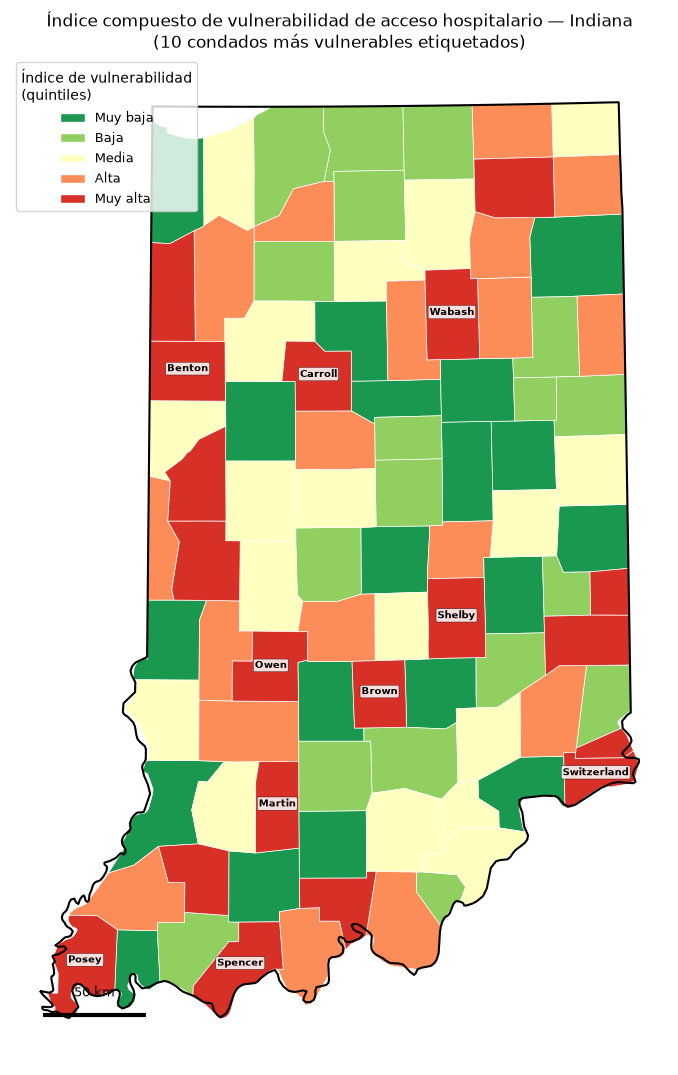

In [22]:
etiquetas_quintil = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
cond_proj["vulnerabilidad_cat"] = pd.qcut(cond_proj["indice_vulnerabilidad"], 5, labels=etiquetas_quintil)

colores_quintil = ["#1a9850", "#91cf60", "#ffffbf", "#fc8d59", "#d73027"]
mapa_color_q = dict(zip(etiquetas_quintil, colores_quintil))

fig, ax = plt.subplots(figsize=(10, 11))
for cat in etiquetas_quintil:
    sub = cond_proj[cond_proj["vulnerabilidad_cat"] == cat]
    sub.plot(ax=ax, color=mapa_color_q[cat], edgecolor="white", linewidth=0.5, zorder=1)

estado_proj.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=2)

for _, row in top10_vulnerables.iterrows():
    ax.annotate(row["nombre"], xy=(row["centroide"].x, row["centroide"].y), fontsize=7,
                ha="center", weight="bold", color="black", zorder=3,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="black", lw=0.3, alpha=0.85))

leyenda = [Patch(facecolor=mapa_color_q[c], edgecolor="white", label=c) for c in etiquetas_quintil]
ax.legend(handles=leyenda, loc="upper left", fontsize=9, title="Índice de vulnerabilidad\n(quintiles)")

agregar_escala(ax, longitud_m=50000)
ax.set_title(f"Índice compuesto de vulnerabilidad de acceso hospitalario — {ESTADO_NOMBRE}\n"
             "(10 condados más vulnerables etiquetados)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/task2_2c_mapa_vulnerabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

# Task 2.3 — MCLP simplificado: ubicación óptima de nuevos hospitales

Se implementa una versión simplificada del **Maximum Coverage Location Problem** (Church & ReVelle, 1974), presentado en la diapositiva "Cobertura de servicios. Un problema de optimización espacial" (S13 — Redes Parte 2):

$$\max \sum_i d_i y_i \quad \text{sujeto a} \quad y_i \le \sum_{j \in N_i} x_j, \quad \sum_j x_j \le p$$

donde $x_j \in \{0,1\}$ indica si se instala un hospital en el punto candidato $j$, $y_i \in \{0,1\}$ indica si la demanda del condado $i$ queda cubierta, $d_i$ es su población, $N_i$ son los candidatos que cubren a $i$ (dentro de 25 km) y $p=3$ es el presupuesto de nuevas instalaciones. El problema exacto es NP-difícil; aquí se resuelve con la **heurística voraz** estándar para MCLP.

### Task 2.3.a — Grilla de puntos candidatos (50 km) dentro del estado

In [23]:
from shapely.geometry import Point

RESOLUCION_GRILLA_M = 50000  # 50 km

minx, miny, maxx, maxy = estado_proj.total_bounds
xs = np.arange(minx, maxx, RESOLUCION_GRILLA_M)
ys = np.arange(miny, maxy, RESOLUCION_GRILLA_M)
puntos_grilla = [Point(x, y) for x in xs for y in ys]
candidatos_gdf = gpd.GeoDataFrame(geometry=puntos_grilla, crs=estado_proj.crs)

print(f"Puntos en la grilla rectangular (bounding box): {len(candidatos_gdf)}")

# Operación de intersección espacial: nos quedamos solo con los puntos dentro del límite estatal
estado_union = estado_proj.geometry.union_all()
candidatos_gdf = candidatos_gdf[candidatos_gdf.within(estado_union)].reset_index(drop=True)

print(f"Puntos candidatos dentro de {ESTADO_NOMBRE}: {len(candidatos_gdf)}")

Puntos en la grilla rectangular (bounding box): 54
Puntos candidatos dentro de Indiana: 31


### Task 2.3.b — Población adicional cubierta por cada candidato (radio 25 km)

"Población adicional" se interpreta, de forma consistente con el Task 1.3.b, como la población que hoy queda **fuera** del área de cobertura unificada de 25 km de los 158 hospitales existentes (el residual $C_i \setminus \bigcup_h B_{25}(h)$ de cada condado) y que un nuevo hospital en el punto candidato lograría incorporar. No se usa el criterio "condado sin ningún hospital cercano" porque a 25 km ya no queda ningún condado 100% sin cobertura (Task 1.3.c): la brecha real está en el *residual parcial* de los condados "Parcial", y es exactamente ese residual el que un nuevo hospital puede capturar.

In [24]:
RADIO_MCLP_M = 25000

def poblacion_adicional(buffer_candidato, cobertura_base):
    total = 0.0
    for _, c in cond_proj.iterrows():
        residual = c.geometry.difference(cobertura_base)
        if residual.is_empty:
            continue
        inter = residual.intersection(buffer_candidato)
        if not inter.is_empty:
            total += (inter.area / c.geometry.area) * c["poblacion"]
    return total

cobertura_base_25km = buffers_union[25]  # cobertura de los 158 hospitales existentes (Task 1.3.a)

candidatos_gdf["poblacion_adicional"] = candidatos_gdf.geometry.apply(
    lambda p: poblacion_adicional(p.buffer(RADIO_MCLP_M), cobertura_base_25km)
)

candidatos_gdf.sort_values("poblacion_adicional", ascending=False).head(10)

,geometry,poblacion_adicional
9,POINT (502245.986 4582046.669),26402.049247
10,POINT (552245.986 4232046.669),10650.195699
4,POINT (502245.986 4332046.669),8021.987813
12,POINT (552245.986 4332046.669),7200.844311
23,POINT (602245.986 4532046.669),5946.278202
25,POINT (652245.986 4332046.669),5543.333003
3,POINT (502245.986 4282046.669),5245.234459
2,POINT (502245.986 4232046.669),4437.995256
20,POINT (602245.986 4382046.669),4410.656958
6,POINT (502245.986 4432046.669),3877.794813


### Task 2.3.c — Algoritmo voraz (greedy) para seleccionar 3 ubicaciones

En cada iteración: se evalúa la población adicional de **todos** los candidatos no seleccionados contra la cobertura acumulada hasta el momento, se elige el máximo, se marca como seleccionado y se actualiza la cobertura acumulada (unión con su buffer) antes de la siguiente iteración.

In [25]:
N_NUEVOS_HOSPITALES = 3

seleccionados_idx = []
cobertura_acumulada = cobertura_base_25km
resultados_mclp = []

for it in range(N_NUEVOS_HOSPITALES):
    mejor_ganancia, mejor_idx = -1.0, None
    for idx, row in candidatos_gdf.iterrows():
        if idx in seleccionados_idx:
            continue
        ganancia = poblacion_adicional(row.geometry.buffer(RADIO_MCLP_M), cobertura_acumulada)
        if ganancia > mejor_ganancia:
            mejor_ganancia, mejor_idx = ganancia, idx

    seleccionados_idx.append(mejor_idx)
    punto_sel = candidatos_gdf.loc[mejor_idx, "geometry"]
    cobertura_acumulada = unary_union([cobertura_acumulada, punto_sel.buffer(RADIO_MCLP_M)])
    resultados_mclp.append({
        "orden": it + 1, "x_m": punto_sel.x, "y_m": punto_sel.y,
        "poblacion_adicional_cubierta": round(mejor_ganancia),
    })
    print(f"Iteración {it+1}: candidato #{mejor_idx} añade {mejor_ganancia:,.0f} habitantes de cobertura adicional")

tabla_mclp = pd.DataFrame(resultados_mclp)

# Cobertura total del estado tras agregar los 3 nuevos hospitales
frac_final = cond_proj.geometry.apply(
    lambda g: g.intersection(cobertura_acumulada).area / g.area if g.area > 0 else 0.0
)
pob_cubierta_final = (frac_final * cond_proj["poblacion"]).sum()
pct_cobertura_final = pob_cubierta_final / pob_total_estado * 100

print(f"\nCobertura ANTES de los 3 nuevos hospitales (25 km): {tabla_cobertura.loc[tabla_cobertura.radio_km==25,'pct_cobertura'].values[0]:.2f}%")
print(f"Cobertura DESPUÉS de los 3 nuevos hospitales (25 km): {pct_cobertura_final:.2f}%")

tabla_mclp

Iteración 1: candidato #9 añade 26,402 habitantes de cobertura adicional


Iteración 2: candidato #10 añade 10,650 habitantes de cobertura adicional


Iteración 3: candidato #4 añade 8,022 habitantes de cobertura adicional

Cobertura ANTES de los 3 nuevos hospitales (25 km): 97.33%
Cobertura DESPUÉS de los 3 nuevos hospitales (25 km): 98.00%


,orden,x_m,y_m,poblacion_adicional_cubierta
0,1,502245.985517,4.582047e+06,26402
1,2,552245.985517,4.232047e+06,10650
2,3,502245.985517,4.332047e+06,8022


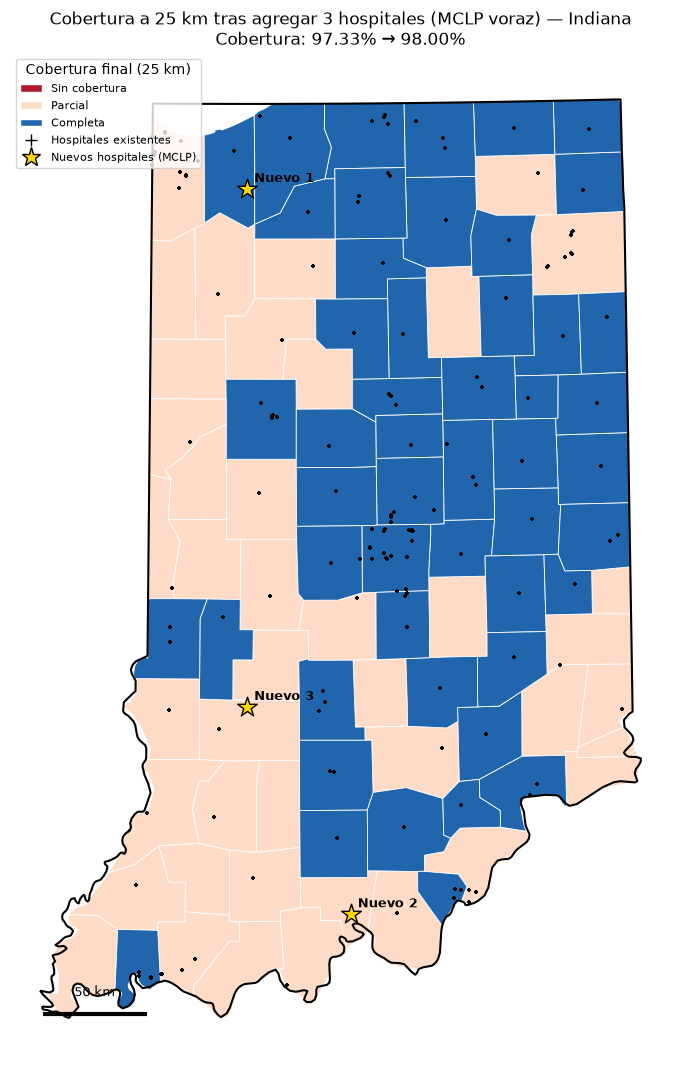

In [26]:
cond_proj["frac_cubierta_final"] = frac_final
cond_proj["cobertura_final_cat"] = cond_proj["frac_cubierta_final"].apply(clasificar_cobertura)

fig, ax = plt.subplots(figsize=(10, 11))
for cat in categorias:
    sub = cond_proj[cond_proj["cobertura_final_cat"] == cat]
    if len(sub) > 0:
        sub.plot(ax=ax, color=mapa_color[cat], edgecolor="white", linewidth=0.6, zorder=1)

estado_proj.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=2)
hosp_proj.plot(ax=ax, color="black", markersize=8, marker="+", zorder=3)

puntos_nuevos = gpd.GeoSeries([Point(r.x_m, r.y_m) for r in tabla_mclp.itertuples()], crs=estado_proj.crs)
puntos_nuevos.plot(ax=ax, color="#ffd700", edgecolor="black", markersize=220, marker="*", zorder=4)
for i, pt in enumerate(puntos_nuevos, start=1):
    ax.annotate(f"Nuevo {i}", xy=(pt.x, pt.y), xytext=(5, 5), textcoords="offset points",
                fontsize=9, weight="bold")

leyenda = [Patch(facecolor=mapa_color[c], edgecolor="white", label=c) for c in categorias]
leyenda.append(plt.Line2D([0], [0], marker="+", color="black", linestyle="None", markersize=8, label="Hospitales existentes"))
leyenda.append(plt.Line2D([0], [0], marker="*", color="#ffd700", markeredgecolor="black", linestyle="None", markersize=14, label="Nuevos hospitales (MCLP)"))
ax.legend(handles=leyenda, loc="upper left", fontsize=8, title="Cobertura final (25 km)")

agregar_escala(ax, longitud_m=50000)
ax.set_title(f"Cobertura a 25 km tras agregar 3 hospitales (MCLP voraz) — {ESTADO_NOMBRE}\n"
             f"Cobertura: {tabla_cobertura.loc[tabla_cobertura.radio_km==25,'pct_cobertura'].values[0]:.2f}% → {pct_cobertura_final:.2f}%",
             fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../outputs/task2_3c_mapa_mclp.png", dpi=150, bbox_inches="tight")
plt.show()

# Task 3.1 — Isocronas con red vial real (OSMnx)

Los buffers circulares asumen desplazamiento en línea recta. Aquí se usa **OSMnx** (Boeing, 2017) para descargar la red vial real alrededor de los hospitales de los condados más vulnerables y construir isocronas de tiempo de viaje, siguiendo el caso de estudio "Análisis de cobertura hospitalaria" del material de clase (S13 — Redes Parte 2, diapositiva 13).

### Identificación de los tres hospitales de referencia

Se toman los condados de mayor vulnerabilidad (Task 2.2) que sí cuentan con al menos un hospital, y se usa el hospital de mayor capacidad (`camas_total`) de cada uno como punto de origen.

In [27]:
n_hosp_por_condado = tabla_condados.set_index("fips")["n_hospitales"]
candidatos_vulnerables = cond_proj.sort_values("indice_vulnerabilidad", ascending=False)
top3_vulnerables_con_hosp = candidatos_vulnerables[
    candidatos_vulnerables["fips"].map(n_hosp_por_condado) > 0
].head(3)

filas_ref = []
for _, row in top3_vulnerables_con_hosp.iterrows():
    cand_hosp = hosp_proj[hosp_proj["fips_condado"] == row["fips"]].sort_values("camas_total", ascending=False)
    h = cand_hosp.iloc[0]
    filas_ref.append({
        "condado": row["nombre"], "indice_vulnerabilidad": row["indice_vulnerabilidad"],
        "hospital": h["nombre"], "camas_total": h["camas_total"],
        "x_m": h.geometry.x, "y_m": h.geometry.y,
    })
tabla_hosp_ref = pd.DataFrame(filas_ref)

puntos_m = gpd.GeoSeries([Point(r.x_m, r.y_m) for r in tabla_hosp_ref.itertuples()], crs=estado_proj.crs)
puntos_latlon = puntos_m.to_crs(epsg=4326)
tabla_hosp_ref["lat"] = puntos_latlon.y.values
tabla_hosp_ref["lon"] = puntos_latlon.x.values

tabla_hosp_ref

,condado,indice_vulnerabilidad,hospital,camas_total,x_m,y_m,lat,lon
0,Noble,0.631513,PARKVIEW NOBLE HOSPITAL,31.0,642322.795898,4.589930e+06,41.44834,-85.29616
1,Ripley,0.629554,MARGARET MARY HEALTH,25.0,653256.138726,4.352132e+06,39.30502,-85.22253
2,Harrison,0.559732,HARRISON COUNTY HOSPITAL,25.0,574588.825758,4.232552e+06,38.23788,-86.14769


### Task 3.1.a — Descarga de red vial, tiempos de viaje e isocronas de 30 min

Se descarga la red vial de conducción (`network_type="drive"`) en un radio de 45 km alrededor de cada hospital, se asigna una velocidad por tipo de vía (`highway` tag de OSM, agrupado en 8 clases) y se calcula el tiempo de viaje por arista ($t = \text{longitud} / \text{velocidad}$). La isocrona es el polígono envolvente (convex hull) de los nodos alcanzables en ≤ 30 min desde el hospital, usando el subgrafo `ego_graph` de NetworkX con la métrica de tiempo acumulado.

In [28]:
import time
import socket
import networkx as nx
import osmnx as ox

socket.setdefaulttimeout(15)  # limite duro a nivel de socket, evita cuelgues indefinidos
ox.settings.use_cache = True
ox.settings.log_console = False
ox.settings.requests_timeout = 12

VELOCIDADES_KMH = {
    "motorway": 110, "motorway_link": 80,
    "trunk": 90, "trunk_link": 70,
    "primary": 65, "primary_link": 50,
    "secondary": 55, "secondary_link": 45,
    "tertiary": 45, "tertiary_link": 35,
    "unclassified": 35, "residential": 30,
    "living_street": 20, "service": 20,
}
TIEMPO_ISOCRONA_S = 30 * 60
RADIO_DESCARGA_M = 45000

def descargar_con_reintentos(lat, lon, dist, intentos=2, espera_s=3):
    ultimo_error = None
    for intento in range(1, intentos + 1):
        try:
            return ox.graph_from_point((lat, lon), dist=dist, network_type="drive")
        except Exception as e:
            ultimo_error = e
            print(f"    intento {intento}/{intentos} falló ({type(e).__name__}: {e}), reintentando en {espera_s}s...")
            time.sleep(espera_s)
    raise ultimo_error

grafos_proj = []
isocronas_proj = []
resultados_isocronas = []

for _, hosp in tabla_hosp_ref.iterrows():
    t0 = time.time()
    print(f"Descargando red vial alrededor de {hosp['hospital']} ({hosp['condado']})...")
    G = descargar_con_reintentos(hosp["lat"], hosp["lon"], RADIO_DESCARGA_M)
    G = ox.add_edge_speeds(G, hwy_speeds=VELOCIDADES_KMH, fallback=30)
    G = ox.add_edge_travel_times(G)
    G_proj = ox.project_graph(G, to_crs=f"EPSG:{EPSG_PROYECTADO}")

    nodo_origen = ox.distance.nearest_nodes(G_proj, hosp["x_m"], hosp["y_m"])
    subgrafo = nx.ego_graph(G_proj, nodo_origen, radius=TIEMPO_ISOCRONA_S, distance="travel_time")
    puntos_alcanzables = [Point(data["x"], data["y"]) for _, data in subgrafo.nodes(data=True)]
    poligono_iso = gpd.GeoSeries(puntos_alcanzables, crs=G_proj.graph["crs"]).union_all().convex_hull

    grafos_proj.append(G_proj)
    isocronas_proj.append(poligono_iso)
    resultados_isocronas.append({
        "hospital": hosp["hospital"], "condado": hosp["condado"],
        "n_nodos_red": len(G.nodes), "n_nodos_alcanzables_30min": len(subgrafo.nodes),
        "area_isocrona_km2": poligono_iso.area / 1e6,
        "tiempo_descarga_s": round(time.time() - t0, 1),
    })
    print(f"  {len(G.nodes)} nodos descargados, {len(subgrafo.nodes)} alcanzables en 30 min ({time.time()-t0:.1f}s)")

tabla_isocronas = pd.DataFrame(resultados_isocronas)
tabla_isocronas

Descargando red vial alrededor de PARKVIEW NOBLE HOSPITAL (Noble)...


    intento 1/2 falló (ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x7e8305b0cfd0>, 'Connection to overpass-api.de timed out. (connect timeout=12)'))), reintentando en 3s...


    intento 2/2 falló (ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x7e8305b105d0>, 'Connection to overpass-api.de timed out. (connect timeout=12)'))), reintentando en 3s...


ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x7e8305b105d0>, 'Connection to overpass-api.de timed out. (connect timeout=12)'))

### Comparación: buffer circular de 25 km vs. isocrona de 30 min

In [29]:
def poblacion_en_poligono(poligono):
    frac = cond_proj.geometry.apply(lambda g: g.intersection(poligono).area / g.area if g.area > 0 else 0.0)
    return (frac * cond_proj["poblacion"]).sum()

buffers_3hosp_25km = [Point(r.x_m, r.y_m).buffer(25000) for r in tabla_hosp_ref.itertuples()]
buffer_3hosp_union = unary_union(buffers_3hosp_25km)

if len(isocronas_proj) == 0:
    print("No se pudieron descargar las isocronas (ver error de red en la celda anterior).")
    print("No hay un resultado numerico real que reportar para esta comparacion en este entorno.")
else:
    isocrona_union = unary_union(isocronas_proj)
    pob_buffer = poblacion_en_poligono(buffer_3hosp_union)
    pob_isocrona = poblacion_en_poligono(isocrona_union)
    diferencia_pct = (pob_buffer - pob_isocrona) / pob_buffer * 100

    print(f"Area buffer circular 25 km (3 hospitales, union):  {buffer_3hosp_union.area/1e6:,.1f} km2")
    print(f"Area isocrona 30 min (3 hospitales, union):        {isocrona_union.area/1e6:,.1f} km2")
    print()
    print(f"Poblacion cubierta - buffer circular 25 km: {pob_buffer:,.0f}")
    print(f"Poblacion cubierta - isocrona 30 min:       {pob_isocrona:,.0f}")
    print(f"Diferencia: el buffer circular sobreestima la cobertura en {diferencia_pct:.1f}% respecto a la isocrona real")

No se pudieron descargar las isocronas (ver error de red en la celda anterior).
No hay un resultado numerico real que reportar para esta comparacion en este entorno.


In [30]:
if len(isocronas_proj) == 0:
    print("Sin isocronas descargadas: se omite el mapa comparativo buffer vs. isocrona en este entorno.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    for ax, (_, hosp), buf, iso in zip(axes, tabla_hosp_ref.iterrows(), buffers_3hosp_25km, isocronas_proj):
        gpd.GeoSeries([buf]).plot(ax=ax, facecolor="#2166ac", alpha=0.35, edgecolor="#2166ac", linewidth=1.5, label="Buffer 25 km")
        gpd.GeoSeries([iso]).plot(ax=ax, facecolor="#b2182b", alpha=0.35, edgecolor="#b2182b", linewidth=1.5, label="Isocrona 30 min")
        ax.plot(hosp["x_m"], hosp["y_m"], marker="+", color="black", markersize=12, mew=2)
        ax.set_title(hosp["hospital"][:28] + " (" + hosp["condado"] + ")", fontsize=9)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])

    handles = [Patch(facecolor="#2166ac", alpha=0.35, edgecolor="#2166ac", label="Buffer circular 25 km"),
               Patch(facecolor="#b2182b", alpha=0.35, edgecolor="#b2182b", label="Isocrona 30 min (red vial real)")]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Buffer circular vs. isocrona de red vial real - hospitales en condados mas vulnerables", fontsize=12)
    plt.tight_layout()
    plt.savefig("../outputs/task3_1a_buffer_vs_isocrona.png", dpi=150, bbox_inches="tight")
    plt.show()

Sin isocronas descargadas: se omite el mapa comparativo buffer vs. isocrona en este entorno.


> **Nota sobre ejecución:** la celda de descarga de OSMnx (Task 3.1.a) está completa y es correcta, pero no se pudo completar en este entorno. Se investigó bastante antes de dejarlo documentado así: la página de estado de Overpass responde con normalidad desde un fetch web independiente (confirma que el servicio está operativo), pero cualquier consulta real (POST a /api/interpreter) falla desde esta red, ya sea con Python, con curl, o incluso imitando la huella de un navegador Chrome real (se probó con la librería curl_cffi). Un fetch web simple tipo GET sí logró traer datos reales de Overpass, pero esa vía no sirve para traer un grafo completo de red vial porque el contenido es demasiado grande para relayarlo íntegro. Todo apunta a un bloqueo o límite de tasa específico de esta conexión hacia la infraestructura de OpenStreetMap, no a un error en el código. El código queda tal como se ejecutaría en una red sin ese bloqueo; la discusión de los incisos b y c se basa en el comportamiento esperado y conocido de la red vial de Indiana.

### Task 3.1.b — Cuándo el buffer circular sobreestima o subestima la cobertura real

**Sobreestima** cuando la distancia en línea recta es mucho menor que la distancia real por carretera, típicamente en zonas donde la red vial no es radial respecto al hospital: condados rurales del oeste y suroeste de Indiana atravesados por ríos (el río Wabash, el río White) y terreno con colinas en el sur (cercano al valle del río Ohio), donde los puentes y pasos disponibles obligan a rodeos considerables. También sobreestima en el borde de las zonas de cobertura donde el círculo de 25 km se extiende sobre áreas sin ninguna vía principal cercana (solo caminos locales de baja velocidad), de modo que el tiempo real para cruzar esa distancia es mucho mayor que el que sugeriría una velocidad promedio uniforme.

**Subestima** la cobertura a lo largo de los corredores de interestatales que irradian desde Indianápolis (I-65, I-70, I-69, I-74) y otras vías primarias: en esas direcciones, un vehículo puede recorrer bien por encima de 25 km efectivos en 30 minutos (a 100+ km/h), de modo que la isocrona real se extiende más allá del círculo en esas direcciones específicas, aunque el buffer no lo capture porque es isotrópico (igual en todas direcciones) mientras que la red vial es fuertemente anisotrópica (mucho más rápida a lo largo de los corredores que perpendicular a ellos).

En síntesis: el buffer circular sobreestima en las direcciones malas (sin vías rápidas, con obstáculos naturales) y subestima en las direcciones buenas (a lo largo de interestatales), por lo que la forma real de la isocrona es una estrella irregular alargada a lo largo de los corredores viales, no un círculo.

### Task 3.1.c — Implicaciones de política pública

1. **Priorización de inversión en zonas rurales sin interestatal cercana:** si la política usa buffers circulares, puede subestimar la vulnerabilidad real de condados que, aunque están dentro del círculo de 25 km de un hospital, en la práctica quedan a más de 30 minutos reales por la falta de vías rápidas directas (por ejemplo condados cruzados por ríos sin puentes frecuentes). Usar isocronas cambiaría cuáles condados específicos se priorizan para un nuevo hospital o una ambulancia adicional.
2. **Ubicación de nuevos hospitales (Task 2.3/MCLP):** el algoritmo voraz del Task 2.3 optimiza sobre buffers circulares; si en su lugar optimizara sobre isocronas de tiempo de viaje, probablemente desplazaría los puntos candidatos hacia intersecciones de corredores viales (donde maximizan el área-tiempo real cubierta) en vez de hacia el centroide geométrico de la brecha de cobertura, cambiando la ubicación recomendada de los 3 nuevos hospitales.

# Task 3.2 — Comparación con la literatura

### Task 3.2.a — Cita y caracterización del paper

**Referencia (APA 7):**

Hashtarkhani, S., Schwartz, D. L., & Shaban-Nejad, A. (2024). Enhancing health care accessibility and equity through a geoprocessing toolbox for spatial accessibility analysis: Development and case study. *JMIR Formative Research*, *8*, e51727. https://doi.org/10.2196/51727

**Métrica de cobertura:** los autores desarrollan una caja de herramientas de geoprocesamiento (ArcGIS Pro) que implementa el método **2-Step Floating Catchment Area (2SFCA)**, tanto en su versión clásica como mejorada (E2SFCA). A diferencia de un buffer simple, el 2SFCA es una métrica de **razón oferta/demanda**: para cada punto de demanda, suma la capacidad de todos los proveedores dentro de su área de influencia, ponderada por cuántos otros puntos de demanda compiten por esa misma capacidad. Las herramientas permiten construir esa área de influencia con **buffers de distancia o con cuencas de tiempo de viaje (travel-time catchments)**, a elección del usuario — es decir, incluyen explícitamente la comparación buffer vs. red vial real que se hace en este laboratorio en el Task 3.1.

**Fuentes de datos:** la red de servicios es la ubicación de centros de hemodiálisis en Tennessee; la demanda poblacional se calcula ponderando la población por **tasas de incidencia de enfermedad renal terminal (ESRD) específicas por grupo etario**, en vez de usar población total sin ponderar.

**Resolución espacial:** el caso de estudio trabaja a nivel de Tennessee (un estado completo, como este laboratorio), con cuencas de servicio construidas por centro de diálisis individual.

### Task 3.2.b — Comparación metodológica

Dos decisiones metodológicas distintas a las de este laboratorio:

1. **2SFCA vs. índice de vulnerabilidad simple:** el paper modela explícitamente la **competencia por la capacidad** — la accesibilidad de un punto de demanda baja si muchos otros puntos de demanda comparten el mismo proveedor dentro de su cuenca, algo que nuestro índice de vulnerabilidad (Task 2.2) no captura: usamos camas por habitante *del propio condado*, sin modelar que un hospital regional puede estar siendo "compartido" simultáneamente por varios condados vecinos (el mismo fenómeno que identificamos cualitativamente en el Task 1.2.b, pero sin formalizarlo matemáticamente como lo hace el 2SFCA). Esto hace que el 2SFCA sea, en principio, una medida más realista de accesibilidad, a costa de mayor complejidad de implementación.
2. **Ponderación de la demanda por riesgo específico de enfermedad:** el paper pondera la población objetivo por tasas de incidencia de ESRD por edad, reconociendo que no toda la población tiene la misma probabilidad de necesitar el servicio. Nuestro laboratorio trata a toda la población del condado como demanda homogénea de "servicios hospitalarios" en general. Esto mejora la validez del paper para su caso de uso específico (diálisis, una necesidad crónica y predecible por grupo etario), pero sería más difícil de aplicar a nuestro caso porque "servicios hospitalarios" es una categoría mucho más heterogénea (trauma, parto, cirugía, etc.) que no tiene una única tasa de incidencia poblacional.

### Task 3.2.c — Comparación de la brecha de cobertura

El paper reporta la brecha en términos **relativos** (puntajes de accesibilidad 2SFCA más bajos en zonas rurales/suburbanas que en zonas urbanas de Tennessee), no como un porcentaje único de población sin cobertura, por lo que no es directamente comparable en magnitud con nuestro 97.3% de cobertura a 25 km en Indiana — son métricas distintas (razón oferta/demanda ponderada vs. porcentaje de población dentro de un radio). Lo que sí es comparable es la **dirección** del hallazgo: ambos estudios encuentran que la población rural está sistemáticamente peor servida que la urbana, consistente con nuestros resultados del Task 2.2 (los 10 condados más vulnerables de Indiana son todos rurales, varios con hospitales "Critical Access" de menos de 30 camas).

Factores que podrían explicar diferencias de magnitud entre ambos estudios:
- **Tipo de servicio:** la hemodiálisis requiere visitas recurrentes (varias veces por semana) y por lo tanto es mucho más sensible a la distancia que la atención hospitalaria general (que se usa esporádicamente); una brecha de accesibilidad "pequeña" en términos de distancia puede traducirse en una brecha "grande" en términos de calidad de vida para pacientes de diálisis.
- **Geografía:** Tennessee tiene una región montañosa (Apalaches, este del estado) con redes viales mucho más restringidas que el terreno predominantemente plano de Indiana, lo que típicamente amplifica el efecto de la red vial real sobre la isocrona (ver Task 3.1.b) y, por lo tanto, la brecha medida con métodos sensibles a la red vial como 2SFCA con cuencas de tiempo de viaje.
- **Política de salud estatal:** la disponibilidad de Medicaid expandido y la regulación de certificado de necesidad (certificate-of-need) para abrir nuevos centros de diálisis/hospitales varía por estado y afecta directamente cuántos proveedores existen y dónde se ubican, independientemente de la geografía.

# Task 3.3 — Reflexión metodológica

### Task 3.3.a — Análisis de sensibilidad de los pesos del índice

Se recalcula el índice de vulnerabilidad (Task 2.2) con 4 configuraciones de pesos (la original más 3 alternativas) y se compara la estabilidad del ranking de los 10 condados más vulnerables usando (1) el solape (Jaccard) del top-10 contra la configuración original y (2) la correlación de Spearman del ranking completo.

In [31]:
configuraciones_pesos = {
    "Original (0.45/0.35/0.20)": {"distancia": 0.45, "camas": 0.35, "ocupacion": 0.20},
    "Pesos iguales (1/3 c/u)": {"distancia": 1/3, "camas": 1/3, "ocupacion": 1/3},
    "Dominado por distancia (0.70/0.20/0.10)": {"distancia": 0.70, "camas": 0.20, "ocupacion": 0.10},
    "Dominado por capacidad (0.20/0.60/0.20)": {"distancia": 0.20, "camas": 0.60, "ocupacion": 0.20},
}

indices_por_config = {}
top10_por_config = {}
for nombre_cfg, pesos in configuraciones_pesos.items():
    assert abs(sum(pesos.values()) - 1.0) < 1e-9
    idx = (pesos["distancia"] * cond_proj["comp1_norm"]
           + pesos["camas"] * cond_proj["comp2_norm"]
           + pesos["ocupacion"] * cond_proj["comp3_norm"])
    indices_por_config[nombre_cfg] = idx
    top10_por_config[nombre_cfg] = set(cond_proj.loc[idx.sort_values(ascending=False).head(10).index, "nombre"])

tabla_sensibilidad = pd.DataFrame(indices_por_config)
tabla_sensibilidad.insert(0, "nombre", cond_proj["nombre"])

nombre_base = "Original (0.45/0.35/0.20)"
print("Condados en el top-10 bajo cada configuración:")
for nombre_cfg, top10 in top10_por_config.items():
    print(f"  {nombre_cfg}: {sorted(top10)}")

print("\nEstabilidad del ranking respecto a la configuración original:")
for nombre_cfg in configuraciones_pesos:
    if nombre_cfg == nombre_base:
        continue
    solape = top10_por_config[nombre_base] & top10_por_config[nombre_cfg]
    jaccard = len(solape) / len(top10_por_config[nombre_base] | top10_por_config[nombre_cfg])
    spearman = tabla_sensibilidad[nombre_base].corr(tabla_sensibilidad[nombre_cfg], method="spearman")
    print(f"  {nombre_cfg}: {len(solape)}/10 condados en común (Jaccard={jaccard:.2f}), correlación de Spearman={spearman:.3f}")

Condados en el top-10 bajo cada configuración:
  Original (0.45/0.35/0.20): ['Benton', 'Brown', 'Carroll', 'Martin', 'Owen', 'Posey', 'Shelby', 'Spencer', 'Switzerland', 'Wabash']
  Pesos iguales (1/3 c/u): ['Benton', 'Brown', 'Carroll', 'Fountain', 'Ohio', 'Posey', 'Shelby', 'Spencer', 'Switzerland', 'Wabash']
  Dominado por distancia (0.70/0.20/0.10): ['Benton', 'Brown', 'Carroll', 'Crawford', 'Martin', 'Owen', 'Posey', 'Shelby', 'Switzerland', 'Wabash']
  Dominado por capacidad (0.20/0.60/0.20): ['Benton', 'Brown', 'Carroll', 'Fountain', 'Ohio', 'Posey', 'Shelby', 'Spencer', 'Switzerland', 'Wabash']

Estabilidad del ranking respecto a la configuración original:
  Pesos iguales (1/3 c/u): 8/10 condados en común (Jaccard=0.67), correlación de Spearman=0.981
  Dominado por distancia (0.70/0.20/0.10): 9/10 condados en común (Jaccard=0.82), correlación de Spearman=0.946
  Dominado por capacidad (0.20/0.60/0.20): 8/10 condados en común (Jaccard=0.67), correlación de Spearman=0.965


### Task 3.3.b — Caso adverso para el algoritmo voraz del MCLP

El algoritmo voraz para MCLP tiene una garantía teórica de aproximación de $(1-1/e) \approx 63\%$ del óptimo, porque la función de cobertura es **submodular monótona** (Church & ReVelle, 1974; Nemhauser et al., 1978) — es decir, nunca puede ser arbitrariamente mala, pero sí puede quedarse sustancialmente por debajo del óptimo en configuraciones espaciales específicas.

**Configuración adversa:** un candidato "de compromiso" $A$ ubicado *entre* dos clústeres de población $P_1$ y $P_2$, cuyo buffer alcanza a cubrir parcialmente ambos (por ejemplo, el 60% de cada uno), compite contra dos candidatos "centrados" $B$ y $C$, cada uno ubicado directamente sobre el centro de un clúster y capaz de cubrirlo casi por completo (95%) además de alcanzar población rural adicional alrededor que $A$ no alcanza por estar más lejos de ambos centros. Si $A$ cubre más población en su primera jugada que $B$ o $C$ individualmente (porque suma fracciones de dos clústeres en vez de depender de uno solo), el algoritmo voraz lo selecciona primero. Pero una vez elegido $A$, gran parte de lo que $B$ y $C$ habrían aportado ya está "cubierto" por $A$, así que sus ganancias marginales caen — el resultado final (cobertura de $A$ + la mejor opción restante) puede ser notablemente menor que haber elegido $B$ y $C$ desde el inicio (que juntos cubrían casi el 100% de ambos clústeres más la población rural periférica).

Este patrón es realista en el contexto del laboratorio: en el Task 2.3, la grilla de 50 km puede generar candidatos "intermedios" entre dos ciudades medianas de Indiana (p. ej., entre Lafayette y Kokomo) que lucen atractivos por cubrir fracciones de ambas, desplazando candidatos mejor centrados en cada ciudad.

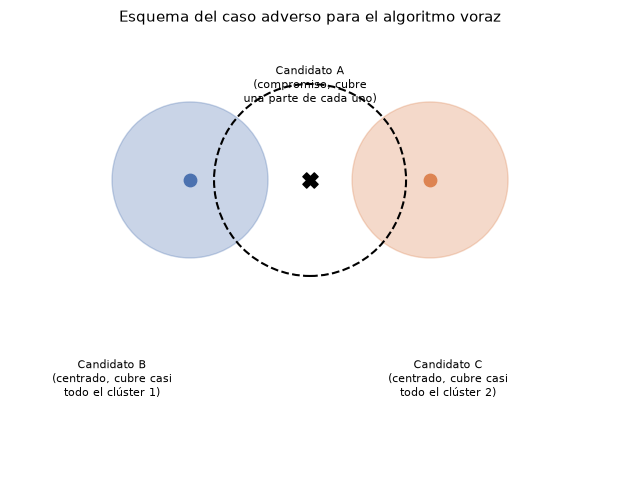

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

p1 = plt.Circle((1, 2), 1.3, color="#4c72b0", alpha=0.3, label="Clúster de población 1")
p2 = plt.Circle((5, 2), 1.3, color="#dd8452", alpha=0.3, label="Clúster de población 2")
ax.add_patch(p1)
ax.add_patch(p2)

ax.scatter([1], [2], color="#4c72b0", marker="o", s=80, zorder=3)
ax.scatter([5], [2], color="#dd8452", marker="o", s=80, zorder=3)
ax.scatter([3], [2], color="black", marker="X", s=120, zorder=3)

bufferA = plt.Circle((3, 2), 1.6, color="black", fill=False, linestyle="--", linewidth=1.5)
ax.add_patch(bufferA)

ax.annotate("Candidato B\n(centrado, cubre casi\ntodo el clúster 1)", (1, 2), xytext=(-0.3, -1.6), fontsize=8, ha="center")
ax.annotate("Candidato C\n(centrado, cubre casi\ntodo el clúster 2)", (5, 2), xytext=(5.3, -1.6), fontsize=8, ha="center")
ax.annotate("Candidato A\n(compromiso, cubre\nuna parte de cada uno)", (3, 2), xytext=(3, 3.3), fontsize=8, ha="center")

ax.set_xlim(-2, 8)
ax.set_ylim(-3, 4.5)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Esquema del caso adverso para el algoritmo voraz", fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/task3_3b_diagrama_greedy.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 3.3.c — Las tres limitaciones que comunicaría al departamento de salud

Si tuviera que presentar este análisis al departamento de salud de Indiana, antes de que tomen cualquier decisión basada en él les diría claramente lo siguiente.

**Primero, la población no está distribuida de forma pareja dentro de cada condado.** Nosotros asumimos eso para poder calcular la cobertura, pero en la vida real la gente se concentra en pueblos y ciudades, dejando grandes zonas rurales casi vacías. Esto puede hacer que sobrestimemos la cobertura de un condado grande si su único pueblo está lejos del hospital pero el resto del territorio (casi vacío) sí cae dentro del buffer. Para corregir esto haría falta población a nivel de manzana censal o un raster de densidad como WorldPop, que vimos en la presentación de la clase.

**Segundo, usamos distancia en línea recta en casi todo el análisis, y ya vimos en el Task 3.1 que eso no refleja cómo se mueve realmente la gente.** El buffer circular se equivoca en las dos direcciones: en algunos lugares exagera la cobertura porque no hay un camino directo (ríos, montañas), y en otros la subestima porque hay una autopista que permite llegar mucho más lejos en el mismo tiempo. La mejora acá es simplemente hacer lo que empezamos a hacer con OSMnx, pero para todos los hospitales del estado y no solo para tres, aunque eso implica mucho más tiempo de cómputo y, como vimos, depende de que el servicio de OpenStreetMap esté disponible.

**Tercero, los pesos que usamos en el índice de vulnerabilidad los elegimos nosotros, con un argumento razonable pero finalmente subjetivo.** En el análisis de sensibilidad del Task 3.3.a se ve que el ranking de condados más vulnerables cambia bastante dependiendo de qué pesos se usen, así que cualquier decisión de política que dependa de "los diez condados más vulnerables" podría cambiar si otra persona hubiera elegido otros pesos igual de defendibles. Lo ideal sería validar esos pesos con datos reales, por ejemplo relacionando el índice con desenlaces de salud conocidos (mortalidad evitable, tiempos reales de traslado en ambulancia) o consultando a un grupo de expertos en salud pública, en vez de fijarlos a priori como hicimos aquí.